# **Task 1 EDA**

In [26]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))
from scripts.data_processing import *

# Load Data

In [27]:
data = pd.read_csv('../data/MachineLearningRating_v3.txt', delimiter='|', low_memory=False)

In [28]:
data.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


# Properties of the Data

In [29]:
data.shape

(1000098, 52)

**There are 1000098 rows and 52 columns in the data.**

In [30]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      959866 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             1000098 non-null  object 
 11  Gender                    1000098 non-null  object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

**There are 37 categorical columns and 15 numerical columns.** <br>
    ===> bool-type -1 <br>
    ===> float-type - 11 <br>
    ===> int-type - 4 <br>
    ===> object - 36 <br>

In [31]:
data.describe()

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


In [32]:
data.columns

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='object')

In [33]:
data.dtypes

UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth             object
IsVATRegistered                bool
Citizenship                  object
LegalType                    object
Title                        object
Language                     object
Bank                         object
AccountType                  object
MaritalStatus                object
Gender                       object
Country                      object
Province                     object
PostalCode                    int64
MainCrestaZone               object
SubCrestaZone                object
ItemType                     object
mmcode                      float64
VehicleType                  object
RegistrationYear              int64
make                         object
Model                        object
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                     object
NumberOfDoors               

# Checking the Quality of Data

# Checking Null Values

In [34]:
print(data.isnull().sum())

UnderwrittenCoverID               0
PolicyID                          0
TransactionMonth                  0
IsVATRegistered                   0
Citizenship                       0
LegalType                         0
Title                             0
Language                          0
Bank                          40232
AccountType                   40232
MaritalStatus                     0
Gender                            0
Country                           0
Province                          0
PostalCode                        0
MainCrestaZone                    0
SubCrestaZone                     0
ItemType                          0
mmcode                          552
VehicleType                     552
RegistrationYear                  0
make                            552
Model                           552
Cylinders                       552
cubiccapacity                   552
kilowatts                       552
bodytype                        552
NumberOfDoors               

# Number of Duplicate Values

In [35]:
print(f"Number of Duplicate rows: {data.duplicated().sum()}")

Number of Duplicate rows: 0


# Missing Values

In [36]:
calculate_missing_percentage(data)

The dataset has 9.51% missing values.


In [37]:
missing_data = check_missing_values(data)
missing_data

,Missing Values,% of Total Values,Data type
NumberOfVehiclesInFleet,1000098,100.00,float64
CrossBorder,999400,99.93,object
CustomValueEstimate,779642,77.96,float64
WrittenOff,641901,64.18,object
Rebuilt,641901,64.18,object
Converted,641901,64.18,object
NewVehicle,153295,15.33,object
AccountType,40232,4.02,object
Bank,40232,4.02,object
VehicleType,552,0.06,object


The dataframe contains 52 columns, of which 22 have missing values. <br>

**Handling Missing values**<br>
Drop columns with a high percentage of missing values and impute remaining missing values.<br>

Drop columns with high percentage of missing values (>50%): <br>
===> NumberOfVehiclesInFleet(100% missing)<br>
===> CrossBorder (99.93 %)<br>
===> CustomValueEstimate(77.96%)<br>
===> Rebuilt(64.18%)<br>
===> Converted(64.18%)<br>
===> WrittenOff(64.18%)<br>

In [38]:
data_cleaned= drop_high_missing_columns(data)

Dropped columns: ['CustomValueEstimate', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet']


**For the remaining data:**<br>
===>For categorical columns, impute missing values using the mode (most frequent value).<br>
===>For numerical columns, use the median to fill in missing values.<br>

In [39]:
data= impute_missing_values(data_cleaned)

**Checking the missing values of the cleaned data.**

In [40]:
missing_data = check_missing_values(data)
missing_data

,Missing Values,% of Total Values,Data type
UnderwrittenCoverID,0,0.0,int64
TermFrequency,0,0.0,object
kilowatts,0,0.0,float64
bodytype,0,0.0,object
NumberOfDoors,0,0.0,float64
VehicleIntroDate,0,0.0,object
AlarmImmobiliser,0,0.0,object
TrackingDevice,0,0.0,object
CapitalOutstanding,0,0.0,object
NewVehicle,0,0.0,object


**Convert the 'VehicleIntroDate' from an object to datetime format to perform time-based analysis.**

In [41]:
data['VehicleIntroDate'] = pd.to_datetime(data['VehicleIntroDate'], utc=True)

# Missing Data Imputation

In [42]:
data['Title'].unique()

array(['Mr', 'Dr', 'Miss', 'Mrs', 'Ms'], dtype=object)

In [43]:
data['Gender'].unique()

array(['Not specified', 'Male', 'Female', 'None'], dtype=object)

In [44]:
count = (data['Gender'] == 'Not specified').sum()

print(count)

940990


In [45]:
# Define mappings for Title to Gender
title_to_gender = {
    'Mr': 'Male',
    'Mrs': 'Female',
    'Miss': 'Female',
    'Ms': 'Female',
}

# Update Gender based on Title where Gender is 'not specified'
data.loc[(data['Gender'] == 'Not specified') & (data['Title'] != 'Dr'), 'Gender'] = data['Title'].map(title_to_gender)

In [46]:
count = (data['Gender'] == 'Not specified').sum()

print(count)

810


# **Univariate Analysis**

Plot histograms for numerical columns and bar charts for categorical columns to understand distributions for the selected key columns from the dataset. <br>

**Distribution of numerical columns**

Histograms for Numerical Columns:


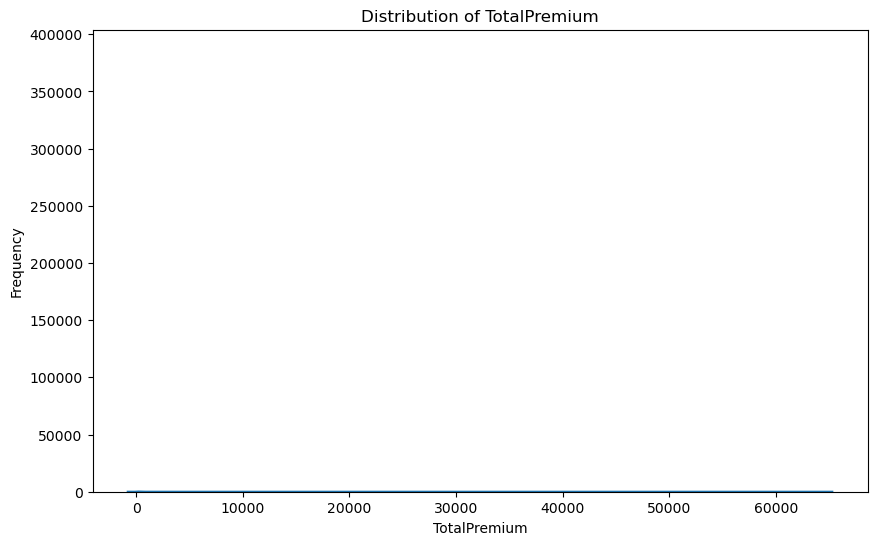

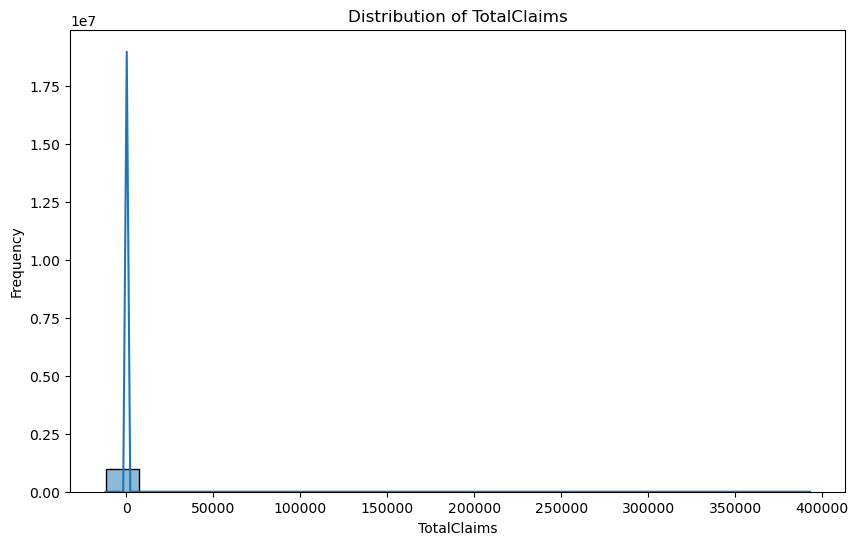

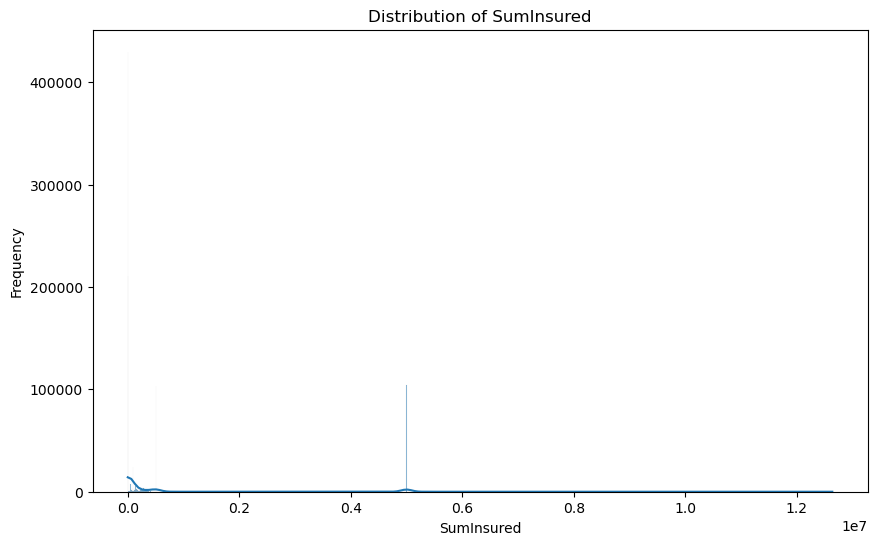

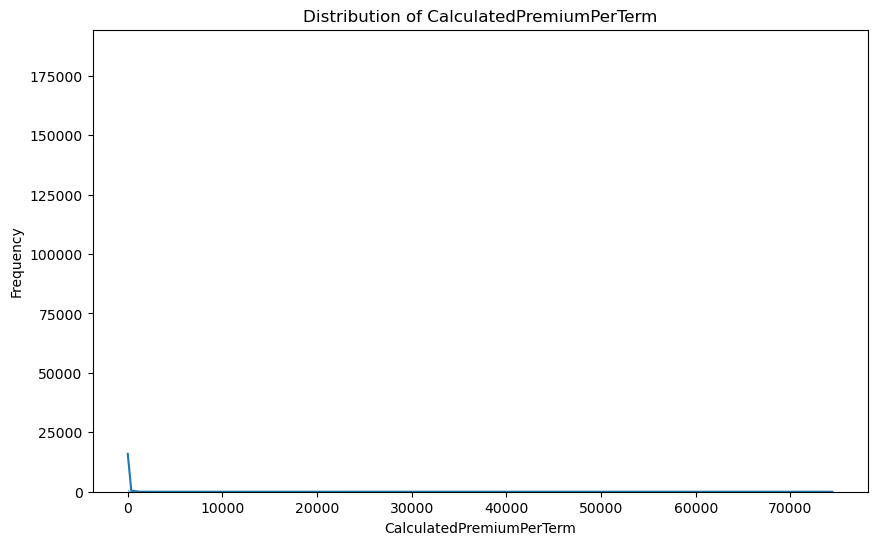

In [47]:
numerical_columns= ['TotalPremium',	 'TotalClaims', 'SumInsured', 'CalculatedPremiumPerTerm']

# Plot histograms for key numerical columns
print("Histograms for Numerical Columns:")
for col in numerical_columns:
    plot_histogram(data, col)

**Distribution of categorical columns**

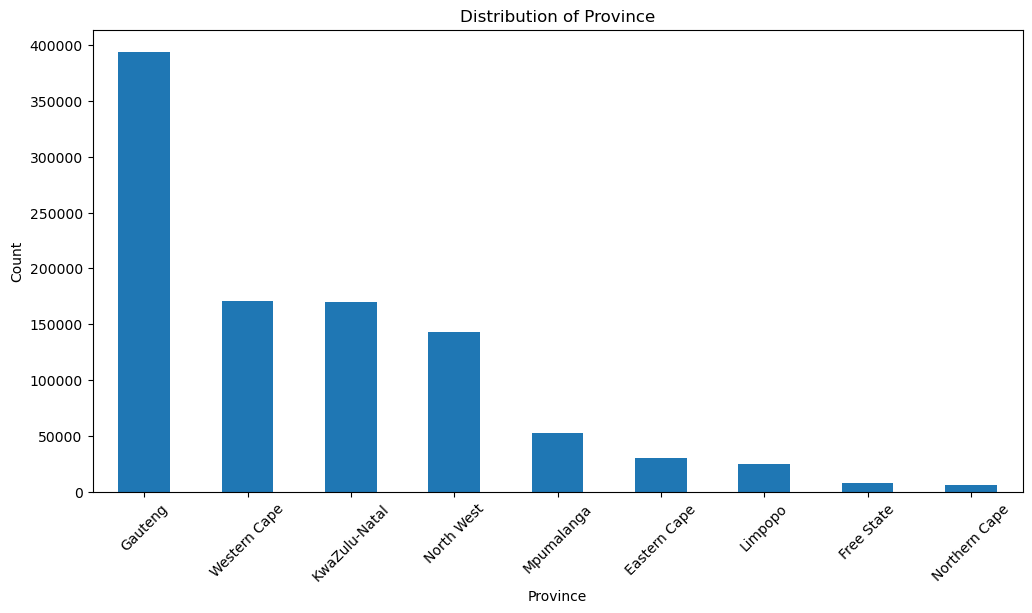

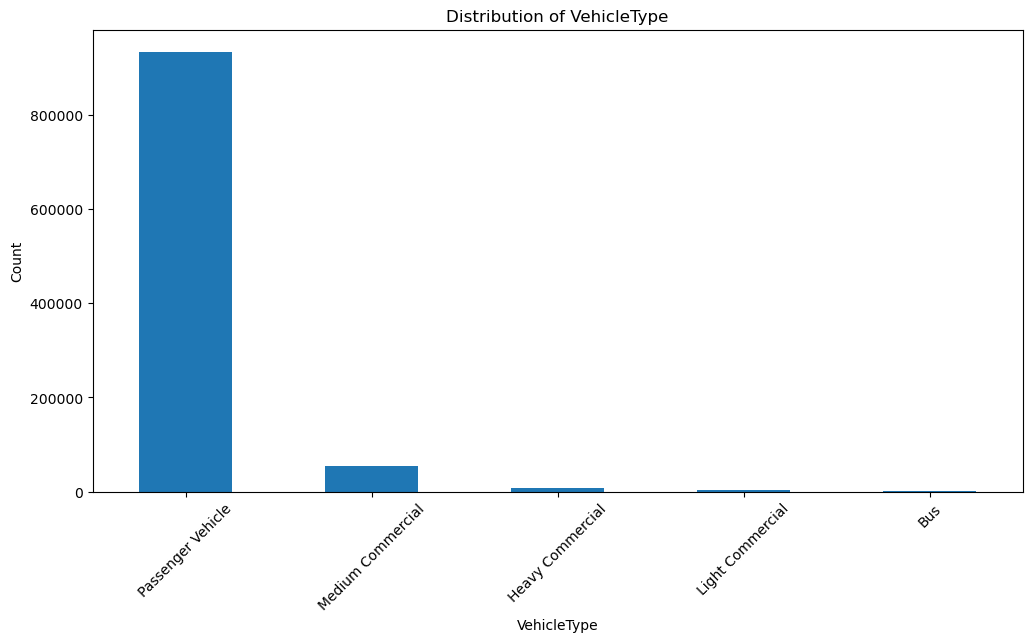

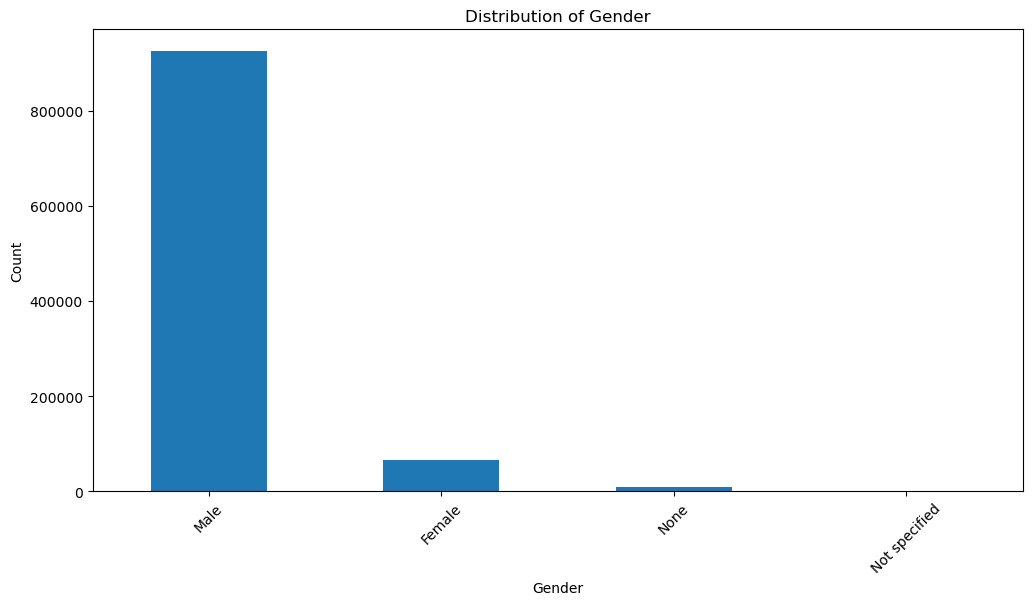

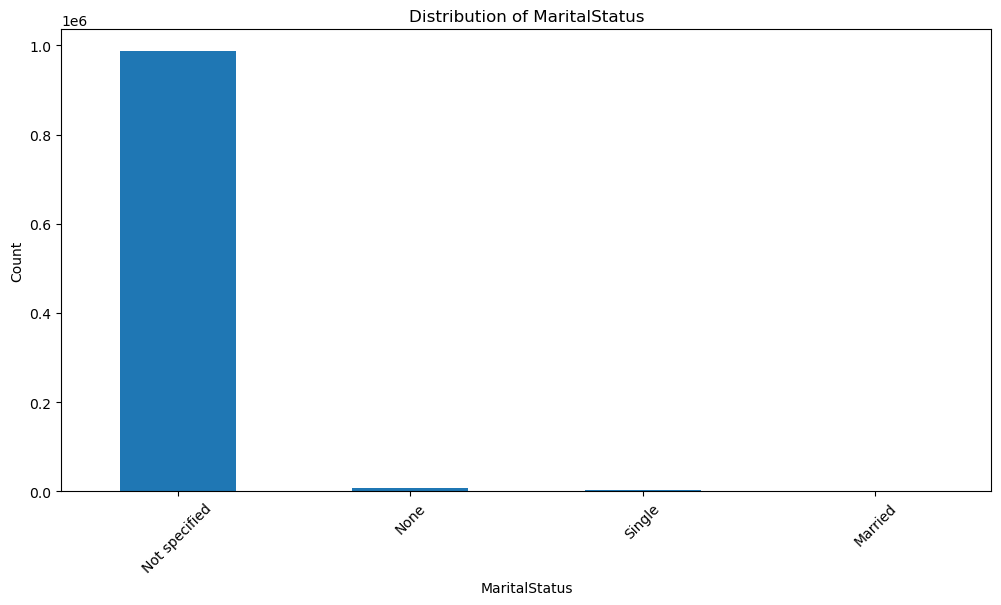

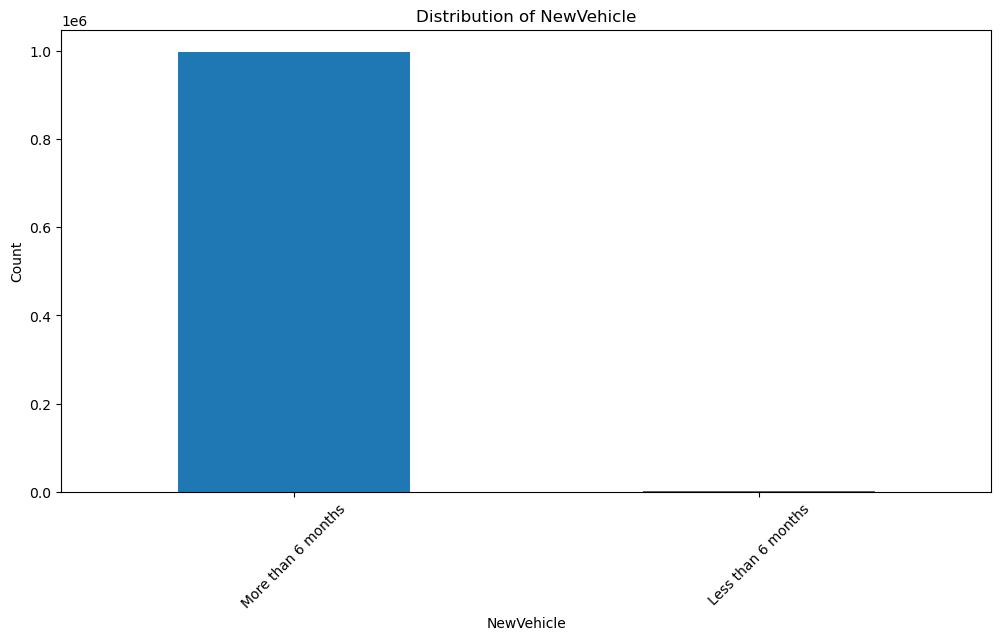

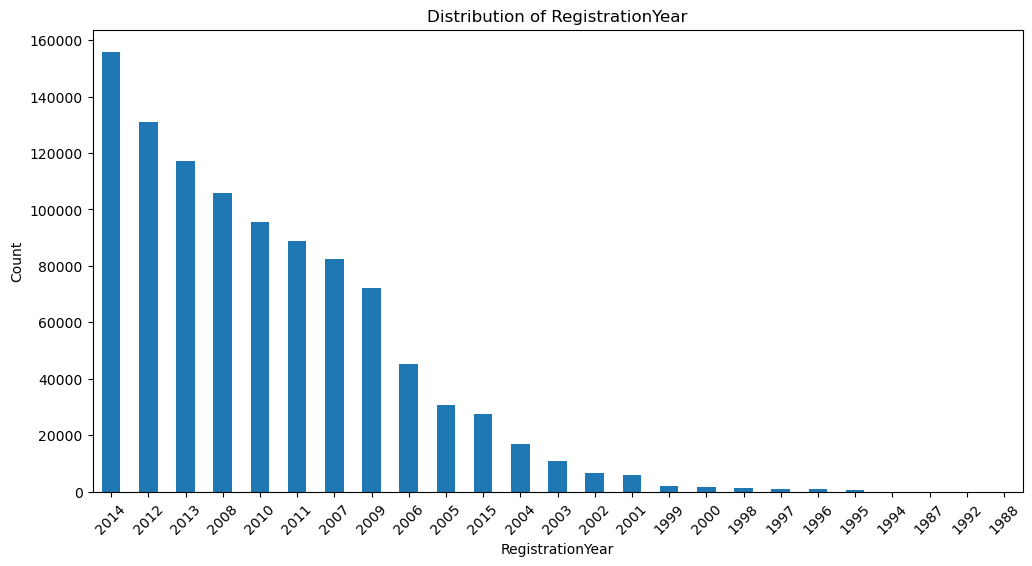

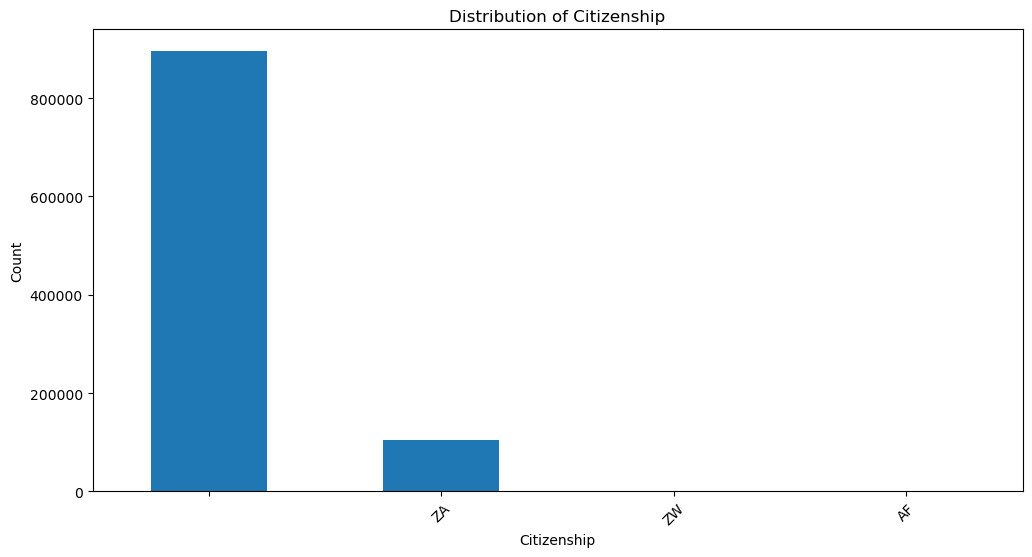

In [48]:
categorical_columns=['Province', 'VehicleType',  'Gender', 'MaritalStatus', 'NewVehicle', 'RegistrationYear','Citizenship' ]


# Plot bar charts for categorical columns
for col in categorical_columns:
    plot_bar_chart(data, col)

**Insights from the univariate analysis of numeric columns:**<br>

- There is a wide distribution across different postal codes, indicating geographical diversity in the customer base.<br>
- Certain vehicle types (such as passenger vehicles) and makes (e.g., Toyota) are overrepresented in the data, suggesting these vehicles are insured more frequently.<br>
- Males tend to be more frequently represented as policyholders than females.<br>

# Bivariate Analysis

Use scatter plots and correlation heatmaps to understand relationships between variables.

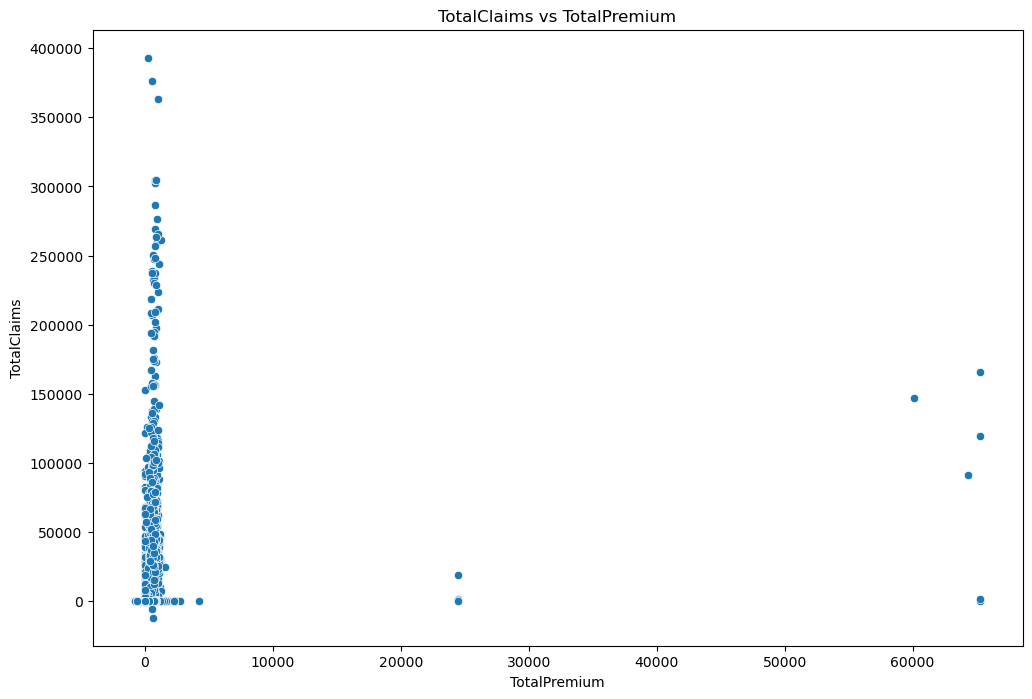

In [49]:
plot_scatter(data, 'TotalPremium', 'TotalClaims')

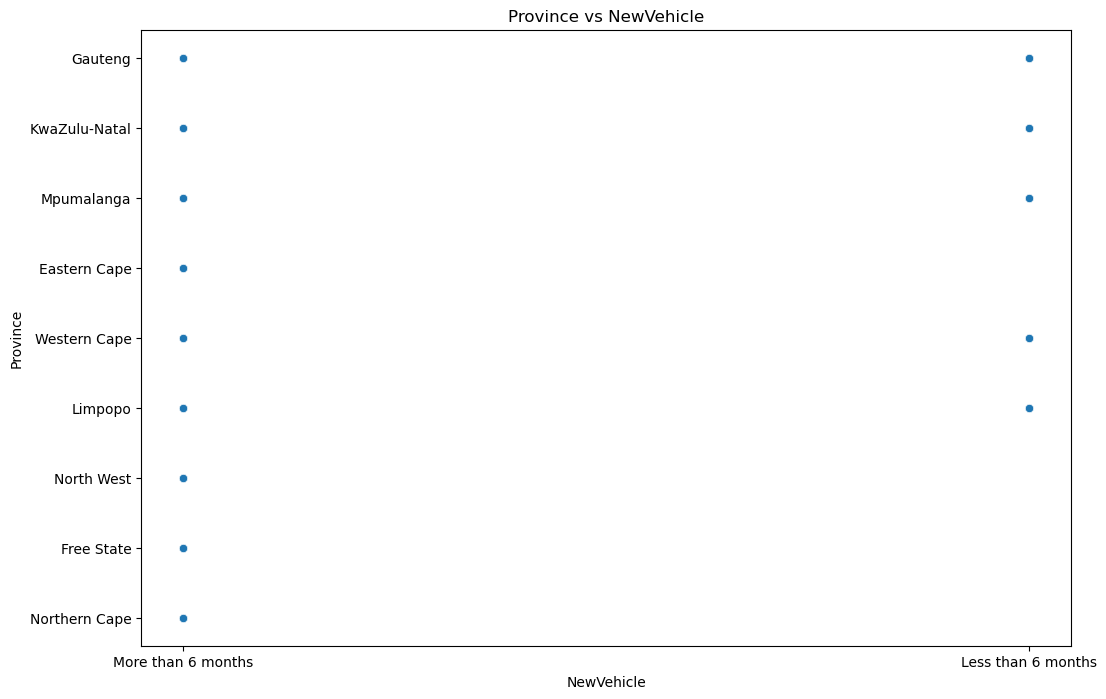

In [50]:
plot_scatter(data, 'NewVehicle', 'Province')

**Examine the correlation between different attributes in our dataset.**

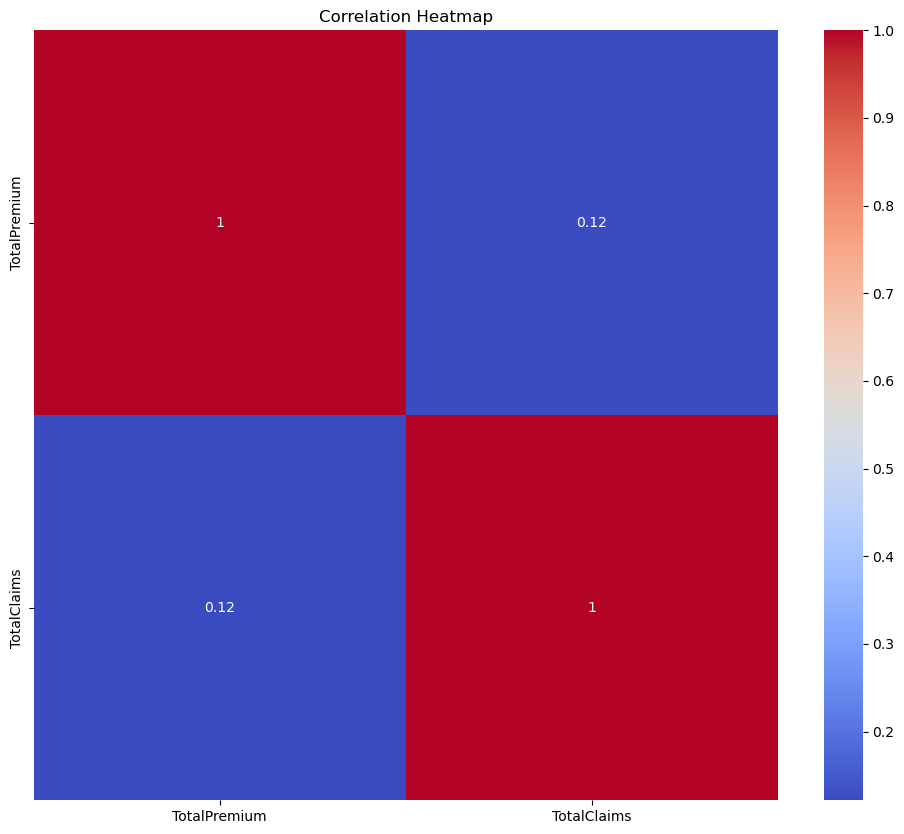

In [51]:
plot_correlation_heatmap(data, ['TotalPremium', 'TotalClaims'])

# Correlation between numerical columns

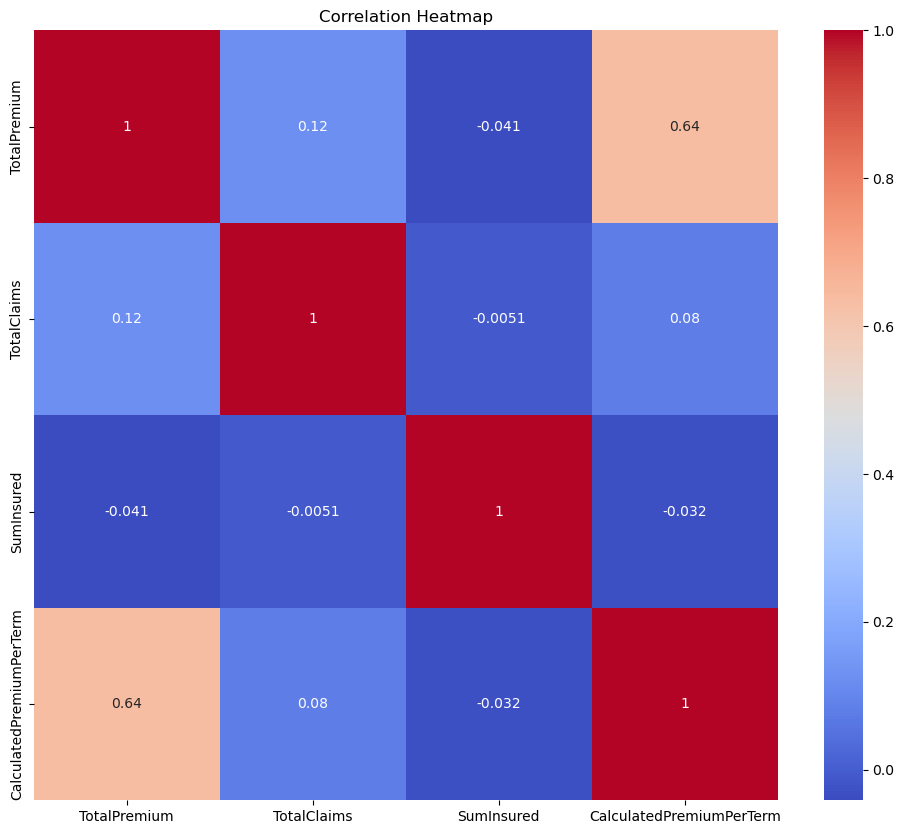

In [52]:
plot_correlation_heatmap(data, numerical_columns)

# Multivariate Analysis

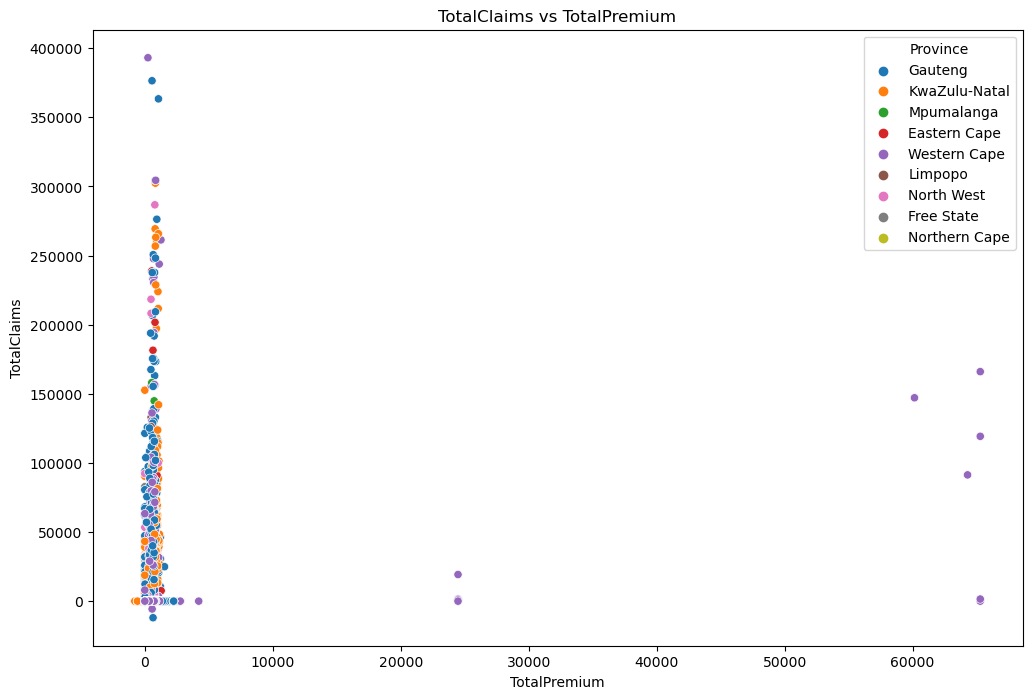

Correlation Matrix of TotalPremium vs TotalClaims by Province
Province
Eastern Cape     0.059646
Free State       0.054746
Gauteng          0.092761
KwaZulu-Natal    0.101787
Limpopo          0.053468
Mpumalanga       0.073857
North West       0.069032
Northern Cape    0.074800
Western Cape     0.203678
Name: TotalPremium, dtype: float64


In [53]:
plot_scatter(data, 'TotalPremium', 'TotalClaims', 'Province')

# Correlation matrix
correlation_matrix_province = data.groupby('Province')[['TotalPremium', 'TotalClaims']].corr().unstack()['TotalClaims']['TotalPremium']

print("Correlation Matrix of TotalPremium vs TotalClaims by Province")
print(correlation_matrix_province)

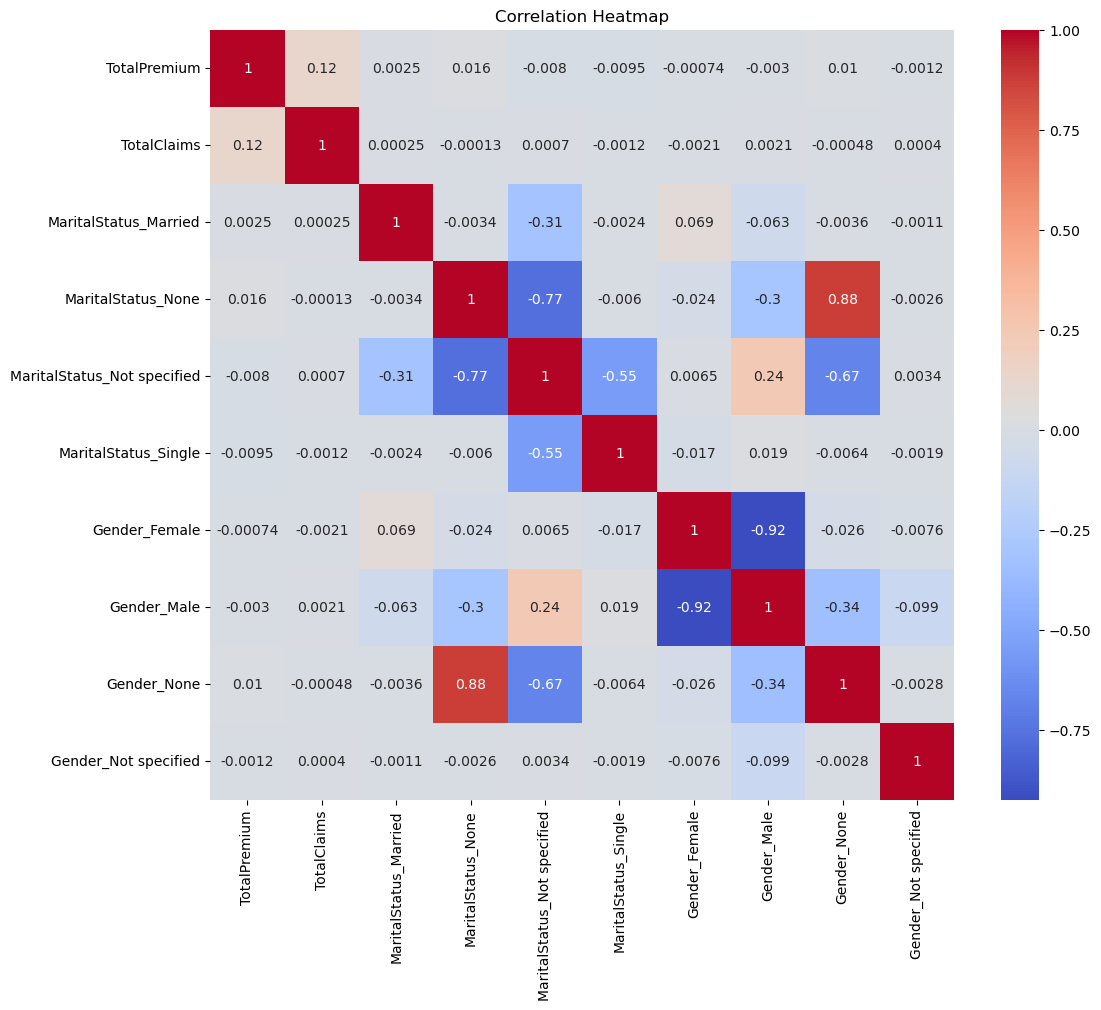

In [54]:
columns=['TotalPremium', 'TotalClaims', 'MaritalStatus', 'Gender']
columns_data = data[columns]

columns_data = pd.get_dummies(columns_data, columns=['MaritalStatus', 'Gender'])
plot_correlation_heatmap(columns_data, columns_data.columns)

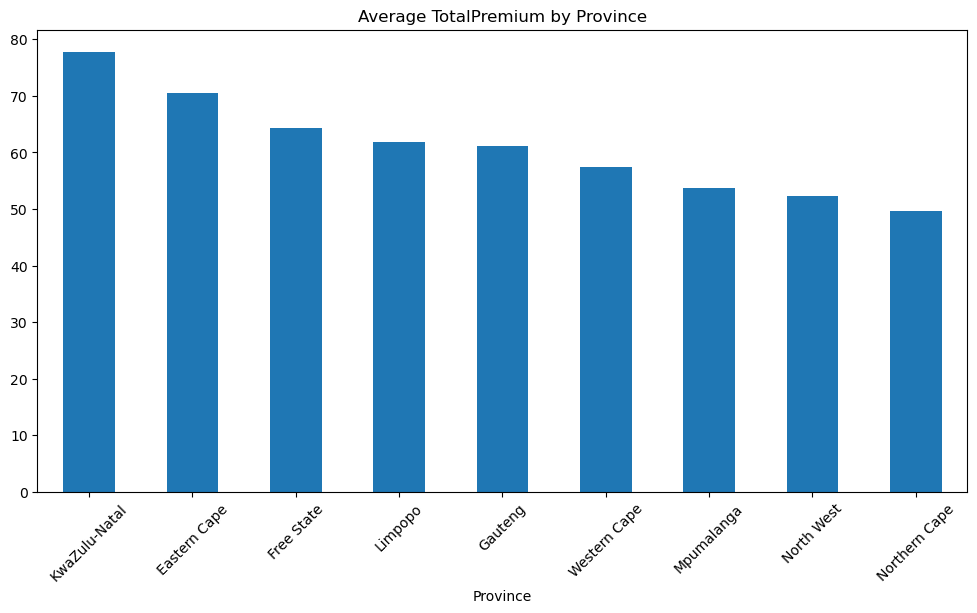

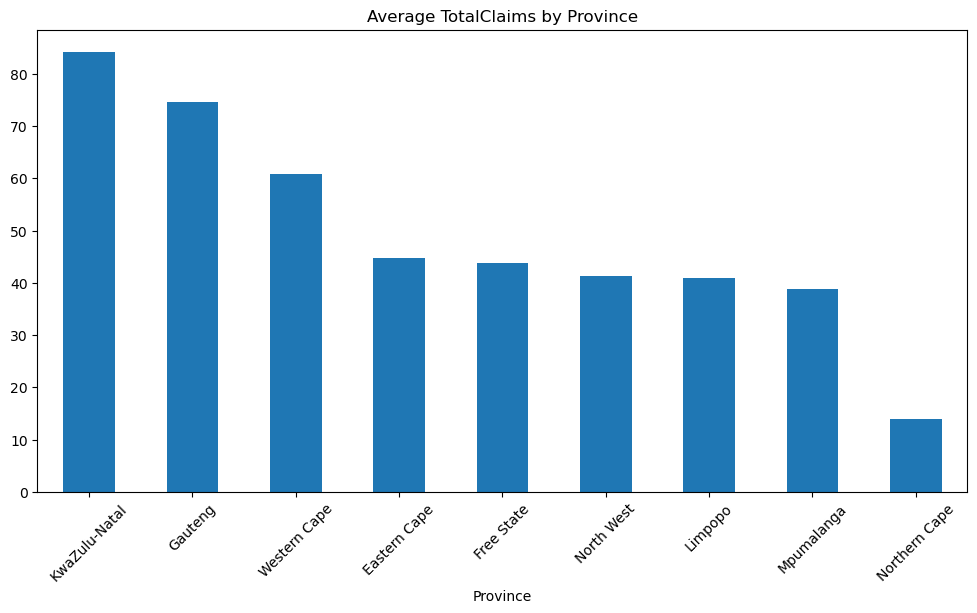

In [55]:
trend_over_geography(data, 'Province', 'TotalPremium')
trend_over_geography(data, 'Province', 'TotalClaims')

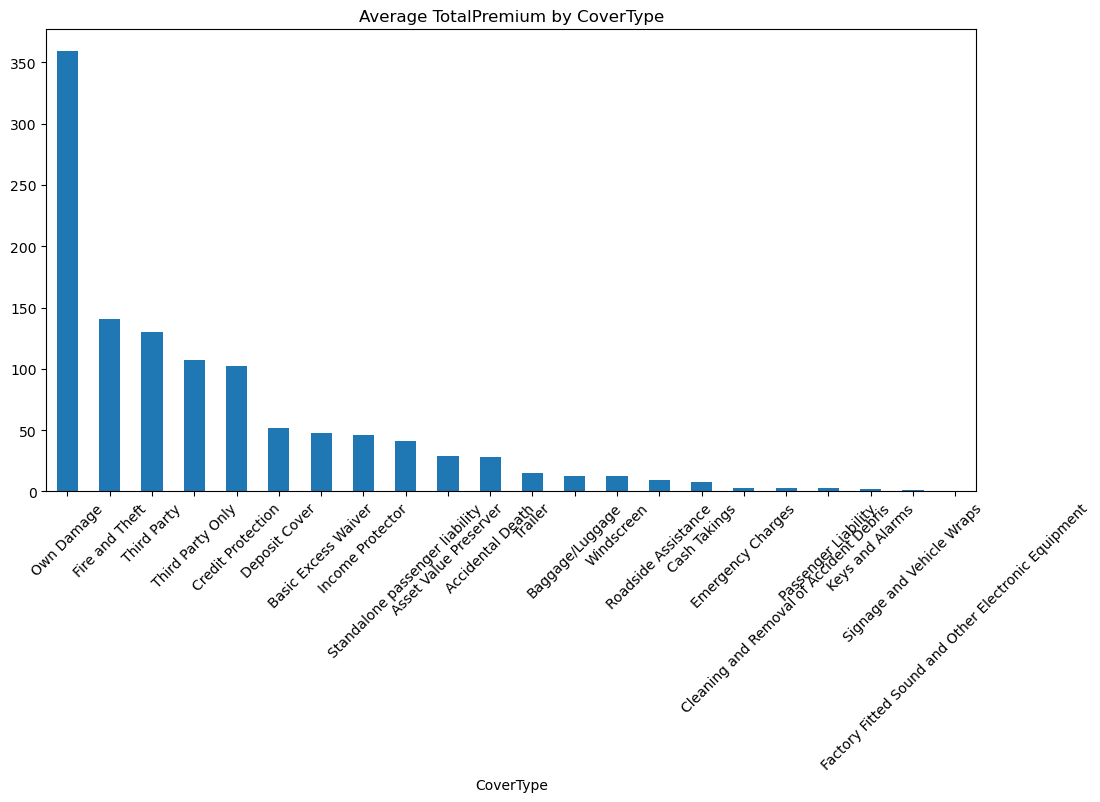

In [56]:
trend_over_geography(data, 'CoverType', 'TotalPremium')

# Outlier Detection

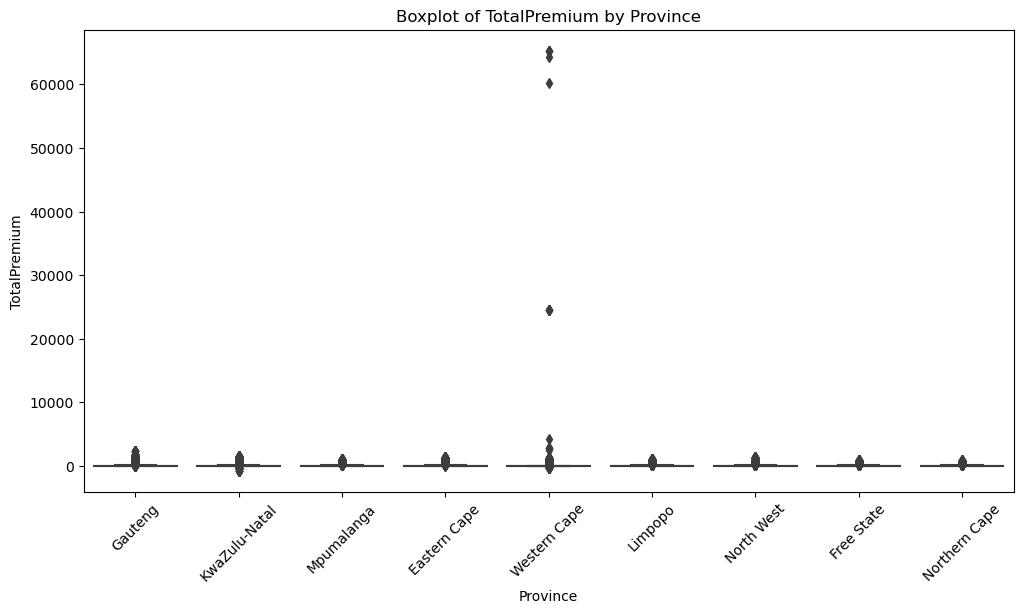

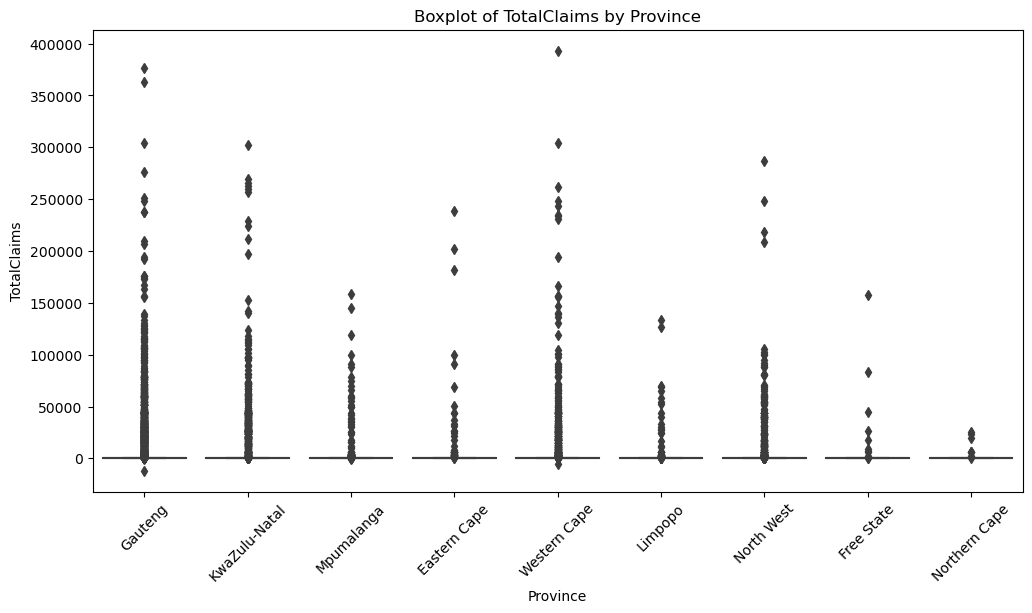

In [57]:
for col in ['TotalPremium', 'TotalClaims']:
    plot_boxplot(data, 'Province', col)

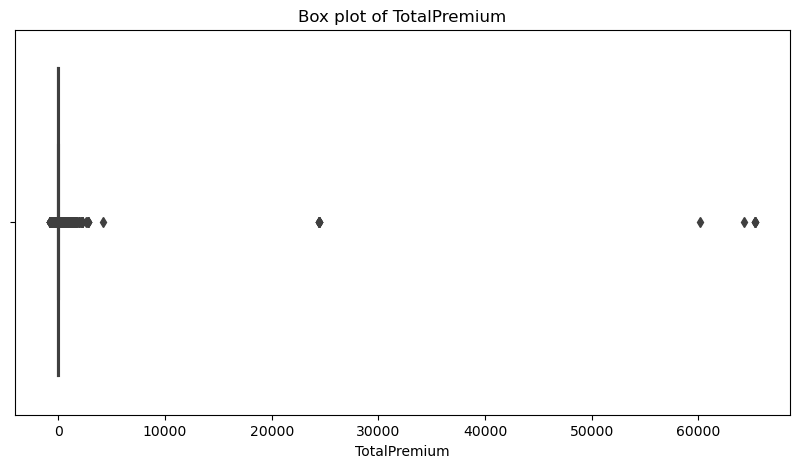

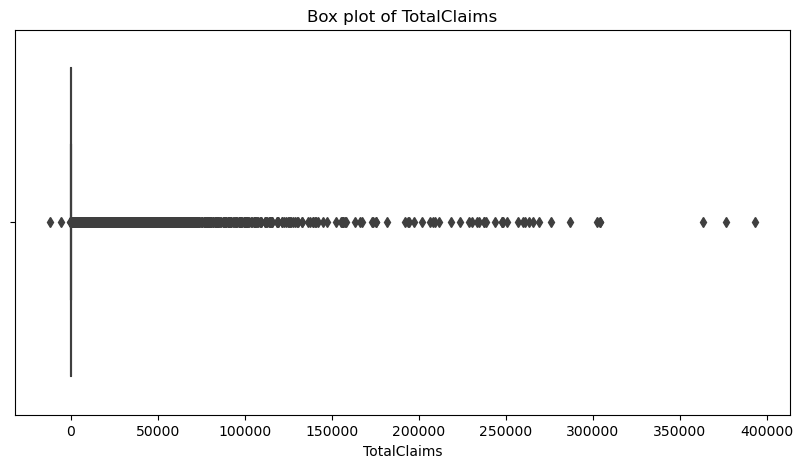

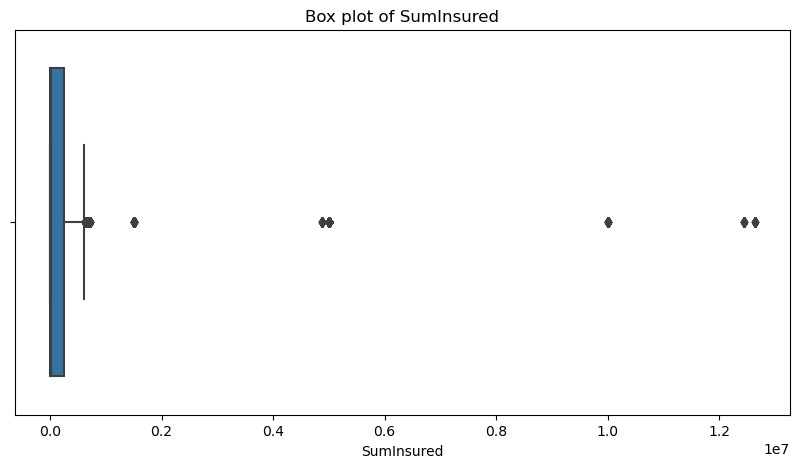

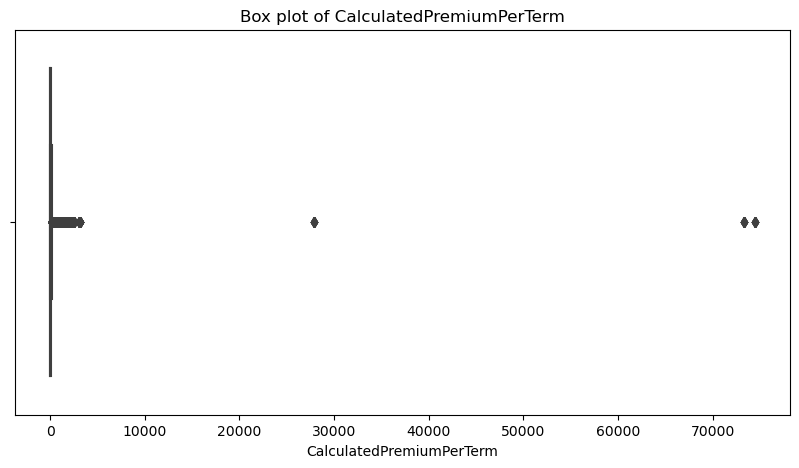

In [58]:
data_numerical_cols = data[numerical_columns]
outlier_box_plots(data_numerical_cols)

# Visualization

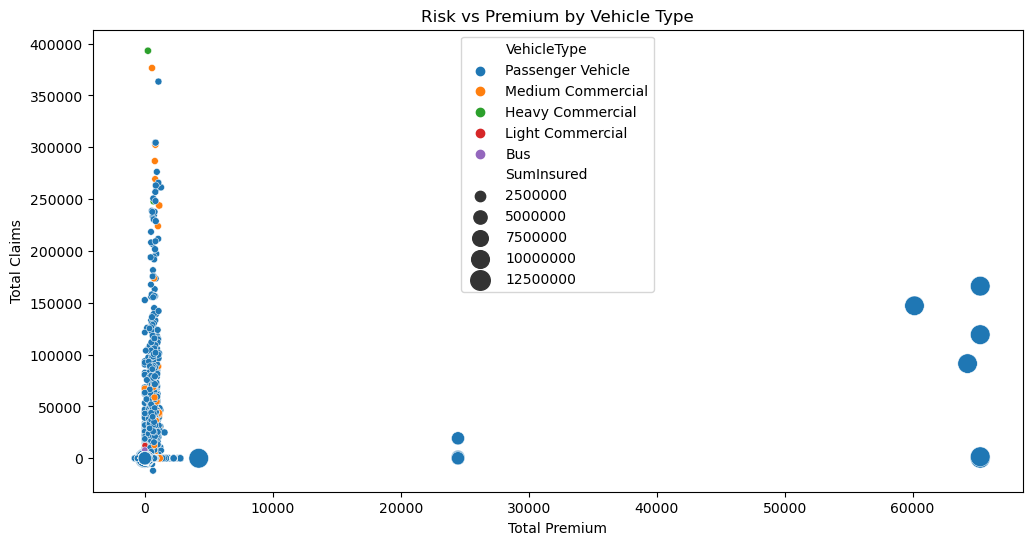

In [59]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data, x='TotalPremium', y='TotalClaims', hue='VehicleType', size='SumInsured', sizes=(20, 200))
plt.title('Risk vs Premium by Vehicle Type')
plt.xlabel('Total Premium')
plt.ylabel('Total Claims')
plt.legend(loc='upper center')
plt.show()

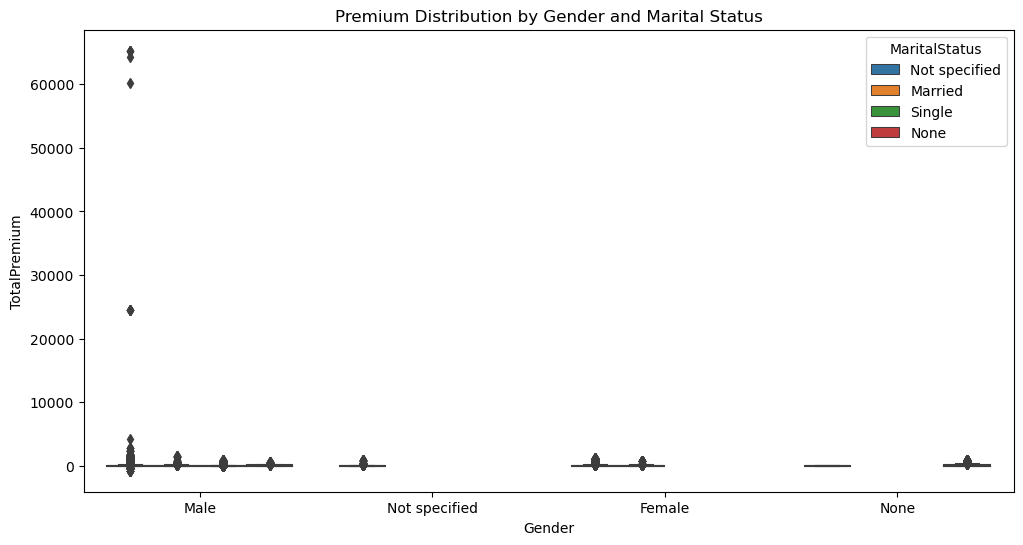

In [60]:
plt.figure(figsize=(12, 6))
sns.boxplot(data, x='Gender', y='TotalPremium', hue='MaritalStatus')
plt.title('Premium Distribution by Gender and Marital Status')
plt.show()

# Outlier Capping Using IQR Method

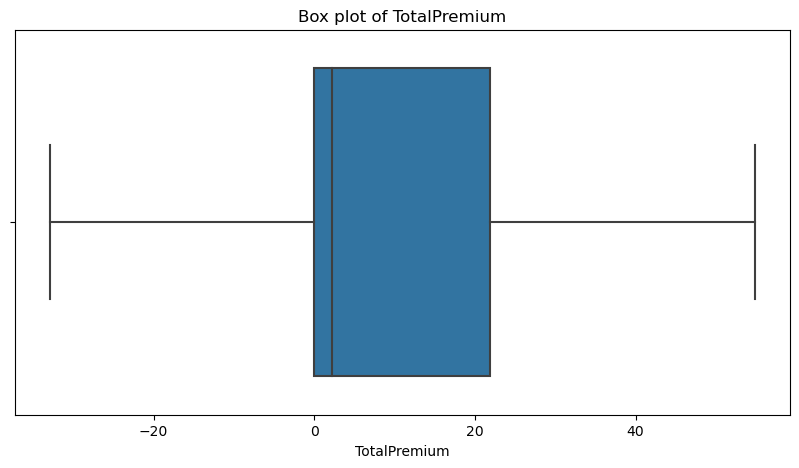

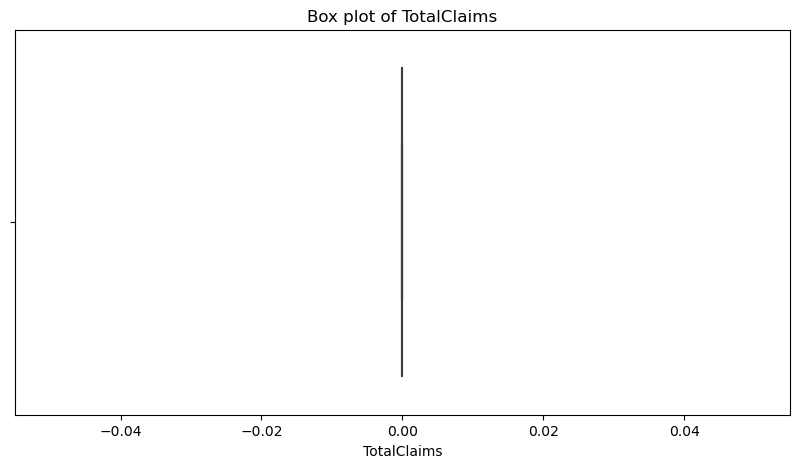

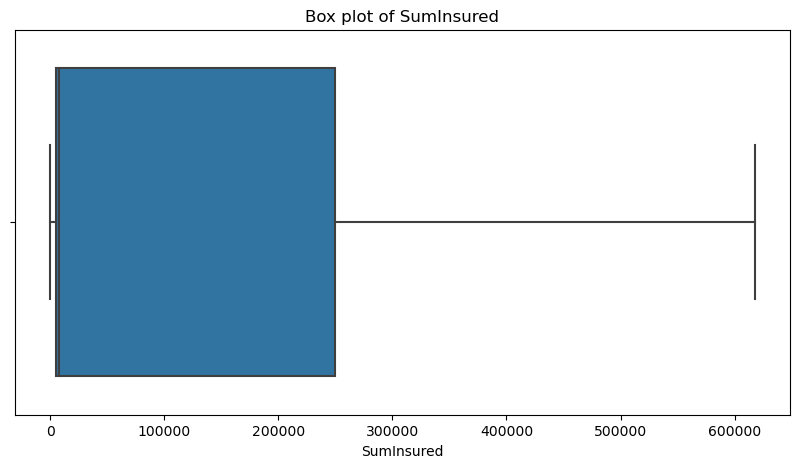

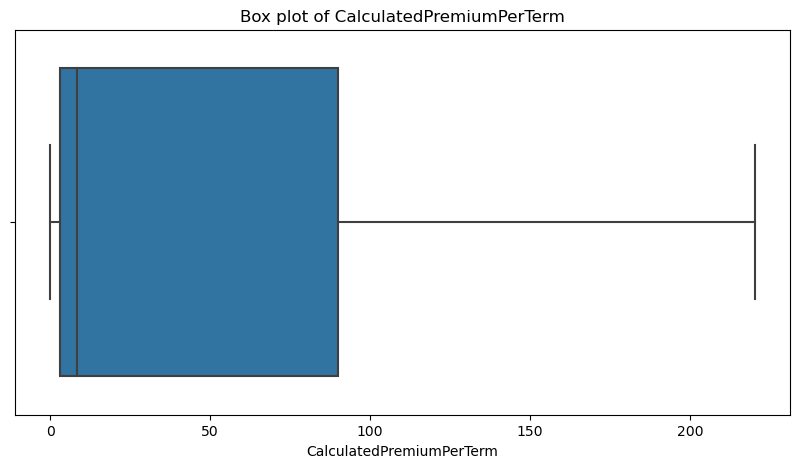

In [61]:
data_capped = cap_outliers(data, numerical_columns)
outlier_box_plots(data_capped[numerical_columns])

In [62]:
data_capped.to_csv('../data/cleaned_insurance_data.csv')